# Principal Components Analysis (PCA)

## Overview

PCA finds the orthogonal linear combinations of features (principal components) that successively maximise variance. The first PC captures the most variance, the second the most of what remains, and so on.

**Key outputs:**

| Output | What it tells you |
|---|---|
| **Eigenvalues / scree plot** | How much variance each PC explains |
| **Loadings** | Which features contribute most to each PC; direction of association |
| **Scores** | Each observation's position in PC space |
| **Biplot** | Observations and variable vectors in the same plot |

**PCA vs. factor analysis:** PCA is a variance decomposition — it explains variance in the observed variables. Factor analysis models latent variables that cause covariance among observed variables. Use PCA for dimensionality reduction and visualisation; use FA when latent constructs are the target of inference.

**Scaling:** PCA on unscaled data is dominated by high-variance features. Always scale to unit variance unless features are on commensurable scales (e.g. all measurements in the same unit).

---

## Setup

In [1]:
library(tidyverse)
library(ggplot2)
library(factoextra)    # fviz_pca_*(), fviz_eig()
library(ggfortify)     # autoplot() for prcomp
library(patchwork)

set.seed(42)

# ── Simulate: 200 water quality monitoring sites, 8 measurements ──────────────
n <- 200
pca_data <- tibble(
  nitrate      = rnorm(n, 4, 1.5),
  phosphorus   = nitrate * 0.15 + rnorm(n, 0, 0.2),   # correlated with nitrate
  ammonia      = nitrate * 0.08 + rnorm(n, 0, 0.1),
  turbidity    = nitrate * 2.5  + rnorm(n, 0, 2),
  water_qual   = 10 - nitrate * 0.6 + rnorm(n, 0, 0.8),
  dissolved_O2 = water_qual * 0.9 + rnorm(n, 0, 0.5),  # correlated with WQ
  conductivity = nitrate * 30 + rnorm(n, 100, 20),
  pH           = 7.5 - nitrate * 0.1 + rnorm(n, 0, 0.3),
  site_type    = factor(sample(c("reference","restored","degraded"), n,
                               replace=TRUE, prob=c(.35,.35,.30)))
)

X <- pca_data %>% select(-site_type)
cat(sprintf("%d observations × %d features\n", nrow(X), ncol(X)))

Warning message:
"package 'tidyverse' was built under R version 4.4.3"
Warning message:
"package 'ggplot2' was built under R version 4.4.3"
Warning message:
"package 'purrr' was built under R version 4.4.3"
Warning message:
"package 'dplyr' was built under R version 4.4.3"
Warning message:
"package 'stringr' was built under R version 4.4.3"
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa

Warning message:
"package 'ggfortify' was bui

200 observations × 8 features


---

## Fit PCA and Inspect Variance Explained

# A tibble: 8 × 3
  PC      var cumvar
  <chr> <dbl>  <dbl>
1 PC1   65.0    65.0
2 PC2   11.2    76.1
3 PC3    9.66   85.8
4 PC4    5.42   91.2
5 PC5    4.71   95.9
6 PC6    2.29   98.2
7 PC7    1.17   99.4
8 PC8    0.62  100  

PCs for 80% variance: 3
PCs for 90% variance: 4


Warning message in geom_bar(stat = "identity", fill = barfill, color = barcolor, :
"Ignoring empty aesthetic: `width`."


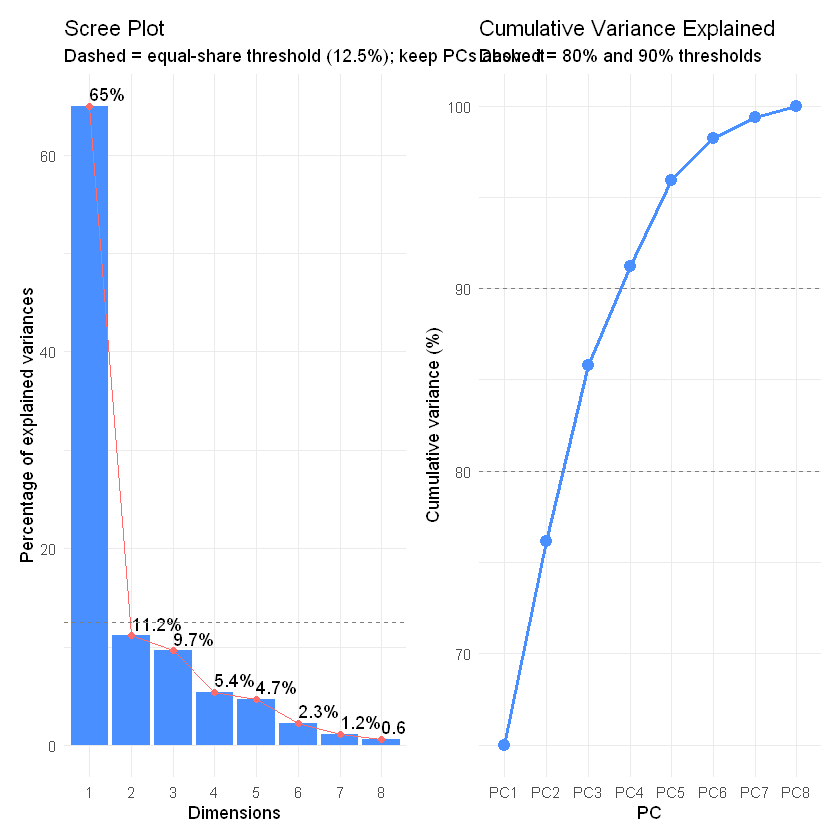

In [3]:
# center=TRUE, scale.=TRUE: standardise to zero mean and unit variance
pca_fit <- prcomp(X, center = TRUE, scale. = TRUE)

# Variance explained
var_exp <- pca_fit$sdev^2 / sum(pca_fit$sdev^2)
cum_var <- cumsum(var_exp)

var_df <- tibble(
  PC     = paste0("PC", seq_along(var_exp)),
  var    = var_exp * 100,
  cumvar = cum_var * 100
)

# round only numeric columns — round() fails on character columns
print(var_df %>% dplyr::mutate(dplyr::across(where(is.numeric), ~round(.x, 2))))

# PCs needed to explain 80% and 90% of variance
cat(sprintf("\nPCs for 80%% variance: %d\n", which(cum_var >= 0.80)[1]))
cat(sprintf("PCs for 90%% variance: %d\n", which(cum_var >= 0.90)[1]))

# ── Scree plot ────────────────────────────────────────────────────────────────
p_scree <- factoextra::fviz_eig(
  pca_fit, addlabels = TRUE, ncp = 8,
  barfill = "#4a8fff", barcolor = NA, linecolor = "#ff6b6b"
) +
  geom_hline(yintercept = 100 / ncol(X), linetype = "dashed", color = "gray50") +
  labs(title    = "Scree Plot",
       subtitle = sprintf("Dashed = equal-share threshold (%.1f%%); keep PCs above it",
                          100 / ncol(X))) +
  theme_minimal()

p_cumvar <- ggplot(var_df, aes(x = PC, y = cumvar, group = 1)) +
  geom_line(color = "#4a8fff", linewidth = 1) +
  geom_point(size = 3, color = "#4a8fff") +
  geom_hline(yintercept = c(80, 90), linetype = "dashed", color = "gray50") +
  labs(title    = "Cumulative Variance Explained",
       subtitle = "Dashed = 80% and 90% thresholds",
       x = "PC", y = "Cumulative variance (%)") +
  theme_minimal()

(p_scree | p_cumvar)

---

## Loadings: What Does Each PC Represent?

# A tibble: 8 × 5
  feature         PC1    PC2   PC3    PC4
  <chr>         <dbl>  <dbl> <dbl>  <dbl>
1 nitrate      -0.419 -0.088 0.177 -0.025
2 phosphorus   -0.348 -0.161 0.104 -0.653
3 ammonia      -0.339 -0.201 0.215  0.747
4 turbidity    -0.382 -0.042 0.328 -0.067
5 water_qual    0.357 -0.472 0.34  -0.064
6 dissolved_O2  0.343 -0.49  0.408 -0.036
7 conductivity -0.395 -0.051 0.237 -0.074
8 pH            0.206  0.677 0.682 -0.018


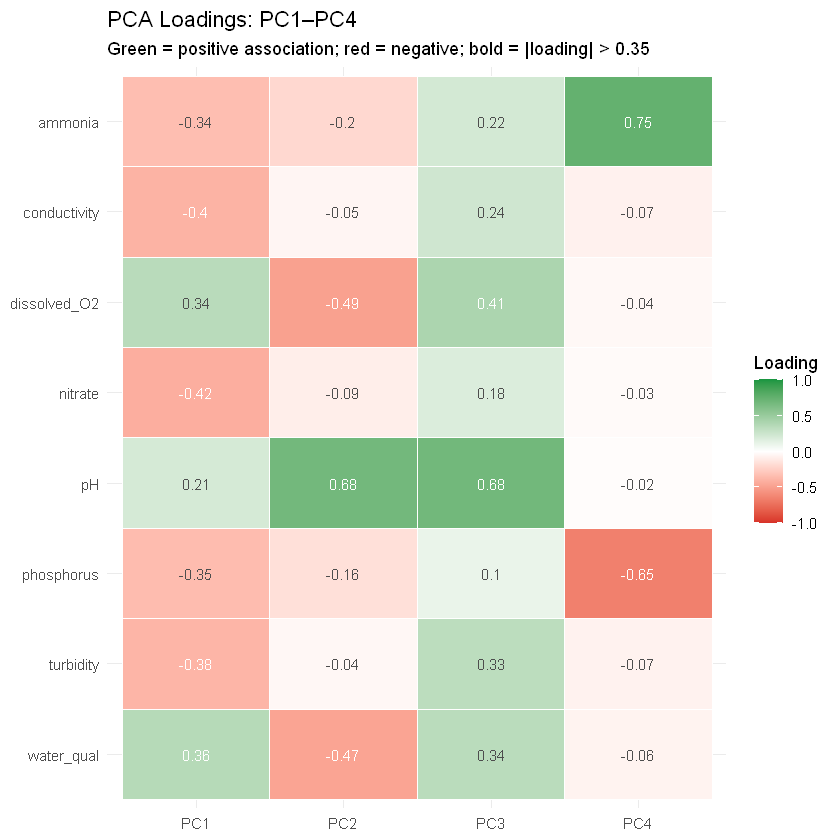

In [4]:
# Loadings = correlation between each original variable and the PC
# (when data is scaled; otherwise divide by sdev)
loadings <- as_tibble(pca_fit$rotation[, 1:4], rownames="feature") %>%
  mutate(across(where(is.numeric), ~round(.x, 3)))
print(loadings)

# ── Loading heatmap ───────────────────────────────────────────────────────────
loadings %>%
  pivot_longer(-feature, names_to="PC", values_to="loading") %>%
  ggplot(aes(x=PC, y=fct_rev(feature), fill=loading)) +
  geom_tile(color="white", linewidth=0.4) +
  geom_text(aes(label=round(loading,2),
                color=abs(loading)>0.35), size=3.2) +
  scale_fill_gradient2(low="#d73027", mid="white", high="#1a9641",
                        midpoint=0, limits=c(-1,1)) +
  scale_color_manual(values=c("TRUE"="white","FALSE"="gray30"), guide="none") +
  labs(title="PCA Loadings: PC1–PC4",
       subtitle="Green = positive association; red = negative; bold = |loading| > 0.35",
       x=NULL, y=NULL, fill="Loading") +
  theme_minimal()

# Interpretation:
# Features with large absolute loadings on a PC define what that PC measures
# Opposite signs = inverse relationship within the PC

---

## Biplot: Observations + Variable Vectors

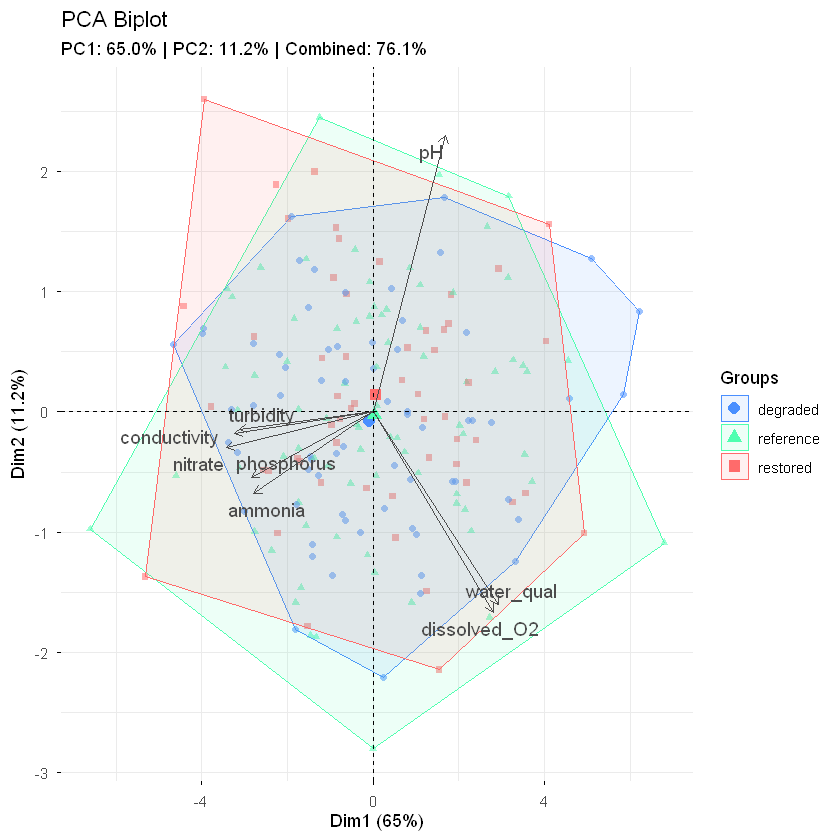

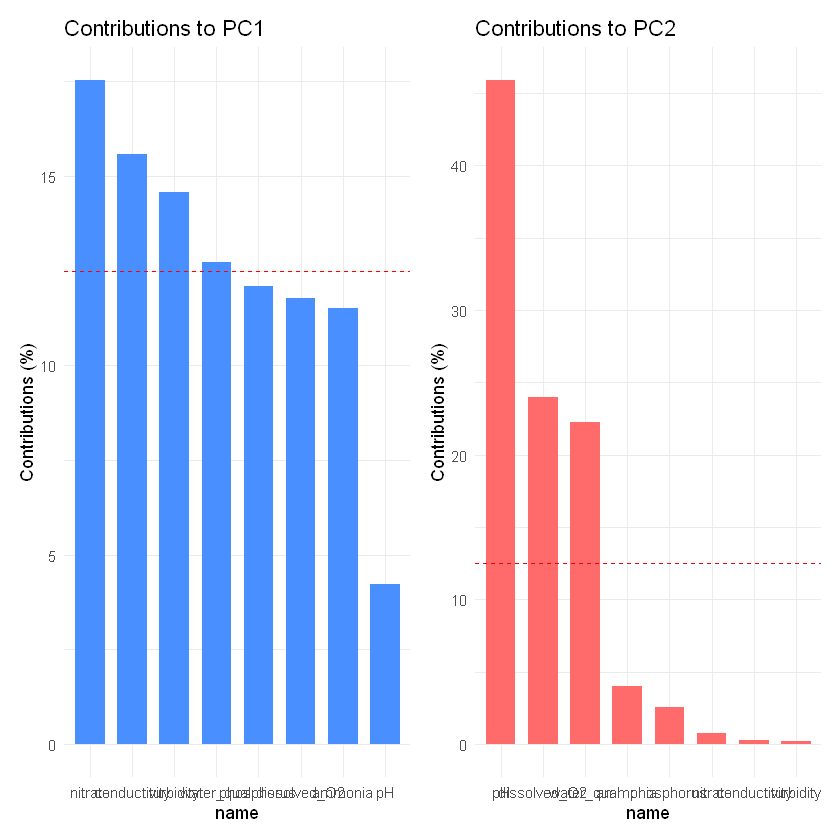

In [5]:
# Biplot: observations (points) + variables (arrows) in same PC space
# Arrow direction: high values of that variable → observations in that direction
# Arrow length: contribution to this plane
# Arrow angle: correlation (small angle = high positive correlation)

factoextra::fviz_pca_biplot(
  pca_fit,
  habillage    = pca_data$site_type,
  palette      = c("#4a8fff","#4fffb0","#ff6b6b"),
  addEllipses  = TRUE, ellipse.type="convex",
  label        = "var",
  col.var      = "gray30",
  alpha.ind    = 0.55,
  repel        = TRUE,
  ggtheme      = theme_minimal()
) +
  labs(
    title    = "PCA Biplot",
    subtitle = sprintf("PC1: %.1f%% | PC2: %.1f%% | Combined: %.1f%%",
                       var_exp[1]*100, var_exp[2]*100,
                       (var_exp[1]+var_exp[2])*100)
  )

# ── Contribution plot: which variables drive PC1 and PC2? ─────────────────────
p_c1 <- factoextra::fviz_contrib(pca_fit, choice="var", axes=1, top=8,
                                   fill="#4a8fff", color=NA) +
  theme_minimal() + labs(title="Contributions to PC1")
p_c2 <- factoextra::fviz_contrib(pca_fit, choice="var", axes=2, top=8,
                                   fill="#ff6b6b", color=NA) +
  theme_minimal() + labs(title="Contributions to PC2")
(p_c1 | p_c2)

---

## PC Scores and Downstream Use

In [6]:
# PC scores: each observation's coordinates in PC space
scores_df <- as_tibble(pca_fit$x) %>%
  bind_cols(site_type=pca_data$site_type)

# Use scores as features in a downstream model
# Select PCs explaining >= 80% variance
n_pcs <- which(cum_var >= 0.80)[1]
pc_features <- scores_df %>% select(PC1:all_of(paste0("PC", n_pcs)))
cat(sprintf("Using %d PCs as features (%.1f%% variance)\n",
            n_pcs, cum_var[n_pcs]*100))

# Predict new observations using the fitted PCA
new_sites <- tibble(
  nitrate=c(2.1, 8.5), phosphorus=c(0.3, 1.2), ammonia=c(0.15, 0.7),
  turbidity=c(5, 22), water_qual=c(9.1, 3.2), dissolved_O2=c(8.8, 4.5),
  conductivity=c(160, 380), pH=c(7.6, 6.9)
)
new_scores <- predict(pca_fit, newdata=new_sites)
cat("\nNew site PC scores:\n")
print(round(new_scores[, 1:3], 3))

Using 3 PCs as features (85.8% variance)

New site PC scores:
        PC1  PC2   PC3
[1,]  3.462 0.30 0.875
[2,] -7.550 0.88 0.642


---

## Common Pitfalls

**1. Not scaling features before PCA**  
PCA maximises variance. A feature with SD = 100 dominates a feature with SD = 0.1 regardless of biological importance. Always use `scale.=TRUE` unless all features are in the same unit and comparable scales. Inspect feature variances with `apply(X, 2, var)` before deciding.

**2. Choosing the number of PCs by the Kaiser criterion alone**  
Kaiser's rule (retain PCs with eigenvalue > 1) was developed for factor analysis of correlation matrices and is a poor general guide. Use the scree plot elbow, the equal-share threshold (eigenvalue > mean eigenvalue), and cumulative variance (80–90%) together. The right number of PCs is context-dependent.

**3. Interpreting PC axes as if they are unique**  
PCA loadings are not unique — any rotation of the PC space explains exactly the same total variance. Varimax rotation (used in factor analysis) often produces more interpretable axes. If interpretation is the primary goal, consider `psych::principal()` with rotation.

**4. Applying PCA to the test set using test set statistics**  
When using PCA as a preprocessing step before modelling, the centering and scaling statistics must come from the training set only. Use `predict(pca_fit, newdata=test)` — this applies the training-set rotation without recomputing statistics from test data.

**5. Reporting biplot interpretation for PC1+PC2 when they explain little variance**  
A biplot of PC1 vs. PC2 is only meaningful if those two PCs capture substantial variance. If PC1 + PC2 explain only 35%, the biplot shows a small and potentially misleading slice of the structure. Report the percentage explained prominently and consider PC3 vs. PC4 or 3D biplots.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*